In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re
from collections import defaultdict

In [11]:
# This will make the nested defaultdict picklable.  
def nested_dict(n, type):
    """
    Creates a nested defaultdict with n levels.

    Parameters:
    n (int): The number of nested levels for the defaultdict.
    type: The default data type for the defaultdict.

    Returns:
    defaultdict: A nested defaultdict with n levels.
    """
    def create_nested_dict(n, type):
        # A helper function that creates a nested defaultdict with n levels
        if n == 1:
            return defaultdict(type)
        else:
            return defaultdict(lambda: create_nested_dict(n-1, type))

    return create_nested_dict(n, type)

def drop_duplicates_except_metric(results,cols,rows):
    # Remove duplicates
    n_rows_before = len(results.index)
    cols_subset = [i for i in results.columns if i != 'test_task_mrr']
    results = results.drop_duplicates(subset=[cols,rows], keep='first')
    n_rows_after = len(results.index)
    print('n_rows_before',n_rows_before, 'n_rows_after', n_rows_after) if n_rows_before != n_rows_after else None
    return results

def string2list(df):
    for column in df:
        try:
            # For all the colum, apply eval() to convert the string to a list
            if column != 'kge':
                df[column] = [np.array(eval(i)) for i in df[column].values]
        except:
            # print("Couldnt convert ", column)
            continue

    # for each col that is a string or int or object, print the unique values 
    print('\nUnique values:')
    for col in df.columns:
        try: 
            if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
                print(col,df[col].unique())
        except:
            continue
    return df

def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    df_std = df.copy()
    for col in df_mean.columns:
        try:
            # df_mean[col] = [i[0] for i in df_mean[col].values]
            vals = []
            # print('col',col, 'df_mean[col].values',df_mean[col].values)
            for i in df_mean[col].values:
                if i is not np.nan:
                    vals.append(i[0])
                else:
                    vals.append(i)
            # substitute the values of the col with the new values
            df_mean[col] = vals
        except:
            continue
    # Do the same for the std
    for col in df_std.columns:
        try:
            # df_std[col] = [i[1] for i in df_std[col].values]
            vals = []
            for i in df_std[col].values:
                if i is not np.nan:
                    vals.append(i[1])
                else:
                    vals.append(i)
            # substitute the values of the col with the new values
            df_std[col] = vals
        except:
            continue
    return df_mean, df_std

In [15]:
tasks = ['countries_s1','countries_s2','countries_s3',
         'nations','kinship_family','pharmkg_small','pharmkg_full',
         'FB15k237','wn18rr']
names_files = [""]# , ,'pharmkg',"long","nations",'kinship']
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\results\\full_test_batch_cleanup\\experiments\\"
for i,file in enumerate(names_files):
    path = root + "experiments"  + file + ".csv"
    dfi = pd.read_csv(path, sep=';', keep_default_na=False, skiprows=1, skip_blank_lines=True, comment='\n')
    dfi = dfi.drop_duplicates()
    if i == 0:
        df = dfi
    else:
        df = pd.concat([df, dfi], ignore_index=True)
df = df.drop_duplicates()
df = string2list(df)
# to avoid problems with the None from Rule miner
df['rule_miner'] = df['rule_miner'].apply(lambda x: 'No' if str(x) == 'None' else x)
print(df)


Unique values:
dataset_name ['countries_s2' 'countries_s3' 'kinship_family']
grounder ['backward_1' 'backward_2' 'backward_3']
kge ['complex']
model_name ['no_reasoner' 'dcr' 'sbr' 'r2n']
rule_miner ['None' 'amie']
kge_atom_embedding_size [100]
batch_size [-1]
val_batch_size [-1]
test_batch_size [-1]
facts_file ['facts.txt']
train_file ['train.txt']
valid_file ['valid.txt']
test_file ['test.txt']
domain_file ['domain2constants.txt']
rules_file ['rules.txt' 'rules_amie.txt']
num_negatives [1]
valid_negatives [100]
format ['functional']
engine_num_negatives [0]
engine_num_adaptive_constants [0]
constant_embedding_size [200]
epochs [100]
num_rules [0 1]
loss ['binary_crossentropy']
cdcr_num_formulas [3]
valid_frequency [3]
reasoner_depth [1]
reasoner_formula_hidden_embedding_size [100]
reasoner_atom_embedding_size [100]
filter_num_heads [3]
run_signature ['countries_s2-backward_1-complex-no_reasoner-None-1-100'
 'countries_s2-backward_1-complex-dcr-None-1-100'
 'countries_s2-backward_1-c

In [16]:
# # Function to replace every cell in the 'Task' column containing 'reason' with the string until 'reason'
# def replace_until_reason(cell_value):
#     match = re.search(r'reason', cell_value)
#     if match:
#         return cell_value[:match.end()]
#     else:
#         return cell_value

# # Apply the function to each cell in the 'Task' column
# df['Task'] = df['Task'].apply(replace_until_reason)
# print(df['Task'].unique())

In [17]:
cols = 'grounder'
rows = 'model_name'
step = 'test'
metrics = [step+'_task_mrr']#, 'time']
KGEs = ['complex'] #, 'distmult', 'transe']
baseline_model = 'no_reasoner'
baseline_metric = step + '_concept_mrr'
# select the rows from df where the column models has the values ['dcr','mno_reasoner'] 
models = ['sbr','rnm','dcr','r2n','no_reasoner'] # ,'gsbr','cdcr'
models_no_baseline = [i for i in models if i != baseline_model]
df = df.loc[df['model_name'].isin(models)]
rule_miners = ['No', 'amie'] 
grounders = ['backward_1', 'backward_2', 'backward_3','domainbody','full'] 

models_name = {'sbr':'SBR', 'rnm':'RNM', 'dcr':'DCR', 'r2n':'R2N', 'no_reasoner':'Baseline'} #, 'gsbr':'GSBR', 'cdcr':'CDCR'
# models_name = {'r2n': 'Relational Reasoning Networks [3]' ,'sbr':'Semantic Based Regularization [2]', 'rnm':'Relational Neural Machines', 'dcr':'Deep Concept Reasoner [4]', 'r2n':'Relational Reasoning Networks[3]', 'no_reasoner':'Baseline'} #, 'gsbr':'GSBR', 'cdcr':'CDCR'
ground_name = {'backward_1':'Known Body', 'backward_2':'Backward 2', 'backward_3':'Backward 3', 'full':'Full', 'domainbody':'DomainBody', 
                'backward_prune_1':'Back. prune 1', 'backward_prune_2':'Back. prune 2', 'backward_prune_3':'Back. prune 3'}
metric_names = {step+'_task_mrr':'MRR', 'time':'Time (s)'}
dataset_names = {'countries_s2': 'Countries S2', 'countries_s3': 'Countries S3', 'countries_s1': 'Countries S1', 'nations': 'Nations', 
                 'kinship_family_small': 'Kinship Family Small', 'kinship_family': 'Kinship', 'pharmkg_supersmall': 'PharmKG Supersmall',
                  'kinship_family_reason_2': 'Kinship Family reason (2)', 'wn18rr': 'WN18RR',
                  'pharmkg_small': 'PharmKG small', 'pharmkg_full': 'PharmKG','pharmkg_small_reason_2': 'PharmKG small Reason',}
model_colors = {'sbr':'#1f77b4', 'rnm':'#ff7f0e', 'dcr':'#2ca02c', 'r2n':'#d62728', 'no_reasoner':'#9467bd'} #, 'gsbr':'#8c564b', 'cdcr':'#e377c2'

# Models in x axis

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [7]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
# create the dict dfs with 4 levels of keys: task, KGE, metric, rule_miner
dfs = nested_dict(4, dict)
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                
                miners_available = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE)]['Rule_Miner'].unique()
                if (rule_miner not in miners_available):
                    print('Not available: rule_miner',rule_miner,'. Available: ',miners_available)
                    continue
                # filter the df
                results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) ].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]
                # Remove duplicates
                results = drop_duplicates_except_metric(results,cols,rows)
                # put the model_name as colums
                results = results.pivot(index=rows, columns=cols, values=metric)

                if metric == 'test_task_mrr':
                    # in the column no_reasoner, put the values of the column test_concept_mrr
                    substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) &(df['Rule_Miner'] == rule_miner) & (df['Model_name'] == baseline_model)][[cols,rows,baseline_metric]] #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    # drop the duplicates , based on all the colums except for 'test_task_mrr'
                    substitute = drop_duplicates_except_metric(substitute,cols,rows)
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    # print('\n\nsubstitute',substitute)
                    # print('\n\nresults',results)
                    if len(substitute) > 0:
                        results.loc[baseline_model] = substitute.loc[baseline_model] 
                    # print('\n\nresults',results)
                
                # obtain one df for the mean and one for the std
                results_mean, results_std = split_df(results)
                # append the results to dfs
                dfs[task][KGE][metric][rule_miner]['mean'] = results_mean
                dfs[task][KGE][metric][rule_miner]['std'] = results_std
                print('\n\nresults_mean',results_mean)
                
                # with open(csv_dir, 'a') as f:
                #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                #     f.write('\n ') 
                # results.to_csv(csv_dir, mode='a', header=True)  
print(task, KGE, metric, rule_miner)
results_mean

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
Not available: rule_miner None . Available:  ['amie']
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie


results_mean Grounder     backward_1  backward_2  backward_3  domainbody    full   known
Model_name                                                                 
cdcr             0.6569      0.6233      0.6219      0.6745     NaN  0.6663
dcr              0.6748      0.6606      0.6691      0.6702  0.6721  0.6470
gsbr             0.6516      0.6533      0.6557      0.6562  0.6535  0.6452
no_reasoner      0.6516      0.6485      0.6538      0.6538  0.6514  0.6467
r2n              0.6538      0.6424      0.6464      0.6575  0.6328  0.6522
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl
Not available: rule_miner ncrl . Available:  ['amie']
KGE:  complex  Metric:  Time  Task:  pharmkg_supersmall  Rule miner:  None
Not available: rul

Grounder,backward_1,backward_2,backward_3,known
Model_name,,,,
cdcr,51.917512,145.466734,276.418879,37.312723
dcr,47.029749,130.528614,214.071812,33.069488
gsbr,41.891804,109.391130,183.840453,25.112712
no_reasoner,20.125511,25.179076,20.065374,19.580590
r2n,42.415282,126.071614,230.843641,31.847271


In [293]:
# # for every df of dfs, create a new df with the average over the models
# dfs_avg = nested_dict(4, dict)
# for task in tasks:
#     for metric in metrics:
#         for KGE in KGEs:
#             for rule_miner in rule_miners:
#                 for types in ['mean', 'std']:
#                     print(types, 'KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                     if rule_miner not in dfs[task][KGE][metric].keys():
#                         continue
#                     dfi = dfs[task][KGE][metric][rule_miner][types].copy()
#                     # select from dfi the models that are in models_no_baseline
#                     dfi = dfi.loc[models_no_baseline]
#                     dfi = dfi.mean(axis=0)
#                     dfi = pd.DataFrame(dfi)
#                     # set the name of the column as the metric
#                     dfi.columns = [metric]
#                     dfs_avg[task][KGE][metric][rule_miner][types] = dfi
#                     # print(dfi)
# dfi

## PLOTS

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  None
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  amie
Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6605      0.6414      0.6283      0.6859  0.6663
dcr              0.7105      0.6738      0.6776      0.6782  0.6650
gsbr             0.6629      0.6664      0.6633      0.6638  0.6635
no_reasoner      0.6622      0.6603      0.6603      0.6699  0.6637
r2n              0.6695      0.6557      0.6502      0.6666  0.6651
<built-in method min of numpy.ndarray object at 0x000001D12DB18F90>


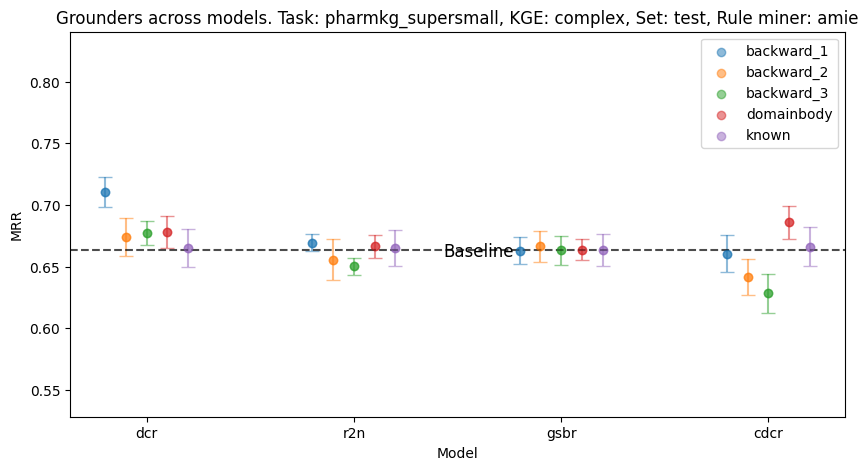

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_supersmall  Rule miner:  ncrl
Grounder     backward_1  backward_2  backward_3  domainbody   known
Model_name                                                         
cdcr             0.6684      0.6878      0.6943      0.6849  0.6635
dcr              0.6644      0.6754      0.6793      0.6764  0.6635
gsbr             0.6663      0.6630      0.6608      0.6631  0.6635
no_reasoner      0.6622      0.6603      0.6603      0.6699  0.6637
r2n              0.6687      0.6651      0.6695      0.6598  0.6653
<built-in method min of numpy.ndarray object at 0x000001D12E9ED290>


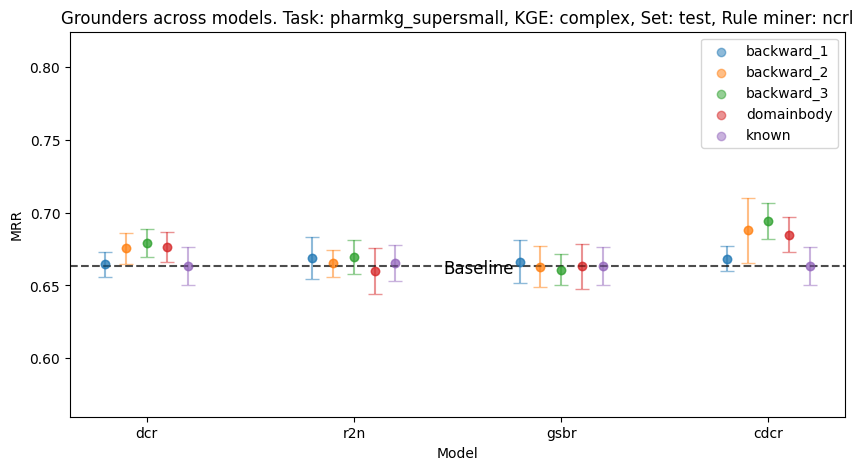

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  None
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5719
dcr              0.6429  0.5691
gsbr             0.6366  0.5693
no_reasoner      0.5800  0.5800
r2n              0.6843  0.5690


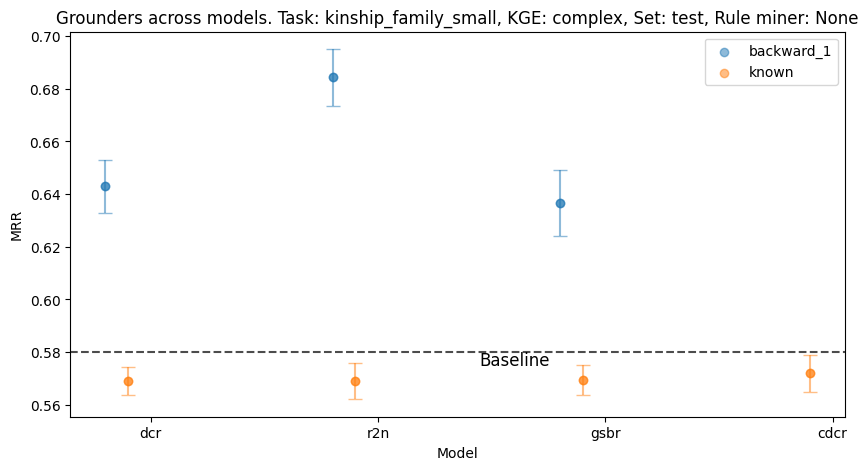

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  amie
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5739
dcr              0.7159  0.5756
gsbr             0.7187  0.5761
no_reasoner      0.5800  0.5797
r2n              0.7760  0.5739


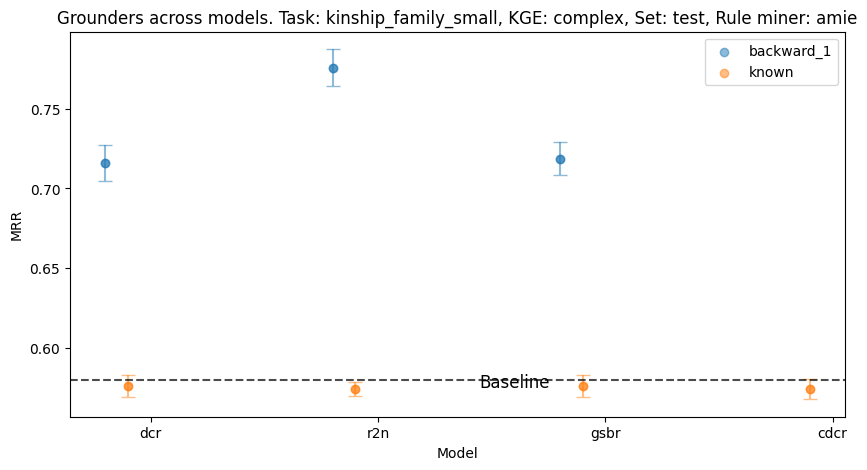

KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family_small  Rule miner:  ncrl
Grounder     backward_1   known
Model_name                     
cdcr                NaN  0.5716
dcr              0.5776  0.5690
gsbr             0.5816  0.5690
no_reasoner      0.5800  0.5800
r2n              0.5784  0.5691


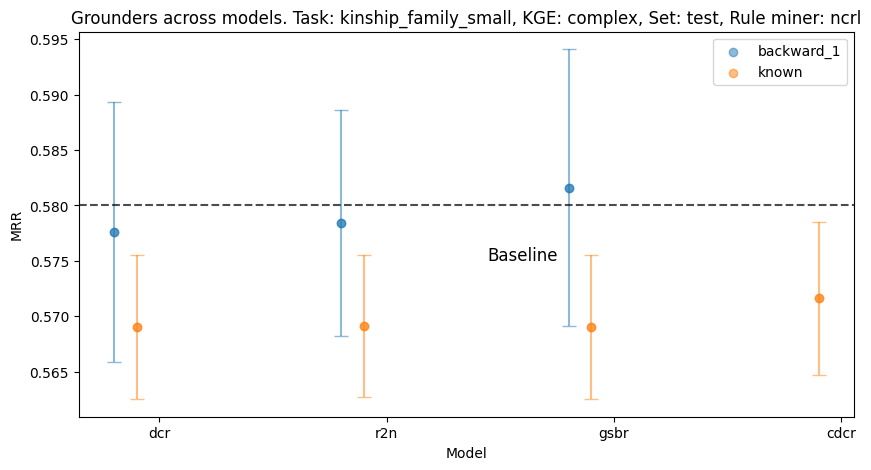

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  None
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.6066         NaN     NaN
dcr              0.6043      0.6013  0.5994
gsbr             0.6040      0.6019     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.6074      0.6073  0.6021


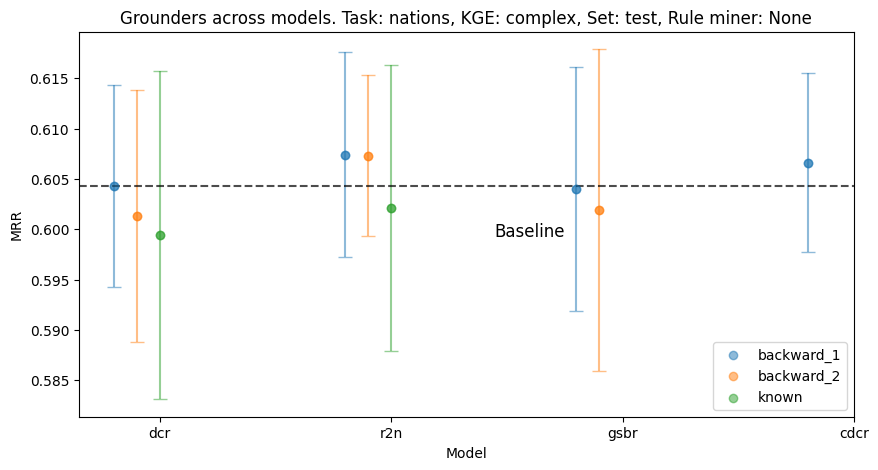

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  amie
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.6122         NaN     NaN
dcr              0.6038      0.6017  0.6011
gsbr             0.5970      0.6016     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.5945      0.6012  0.6003


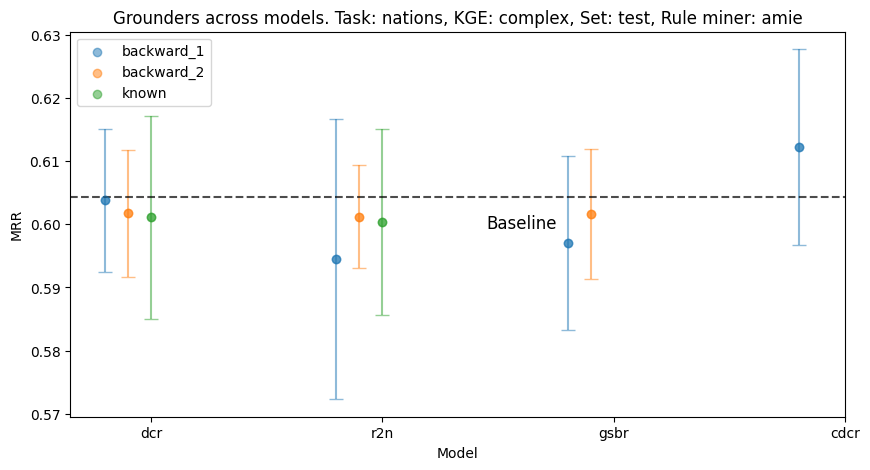

KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  ncrl
Grounder     backward_1  backward_2   known
Model_name                                 
cdcr             0.5978         NaN     NaN
dcr              0.6077      0.6015  0.5994
gsbr             0.6022      0.5997     NaN
no_reasoner      0.6043         NaN     NaN
r2n              0.6030      0.6037  0.6021


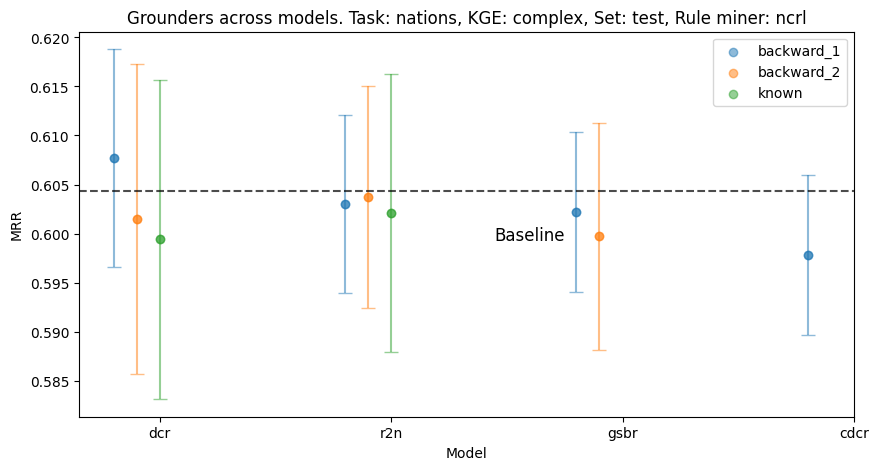

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  None
Grounder     backward_1  backward_2  backward_3  domainbody    full   known
Model_name                                                                 
cdcr             0.7550      0.7855      0.7855      0.7661  0.7680  0.7481
dcr              0.7615      0.7481      0.7481      0.7361  0.7557  0.7433
gsbr             0.7595      0.7582      0.7582      0.7601  0.7747  0.7473
no_reasoner      0.7414      0.7414      0.7414      0.7414  0.7414  0.7414
r2n              0.7382      0.7511      0.7511      0.7105  0.7741  0.7640
<built-in method min of numpy.ndarray object at 0x000001D12BFFF3F0>


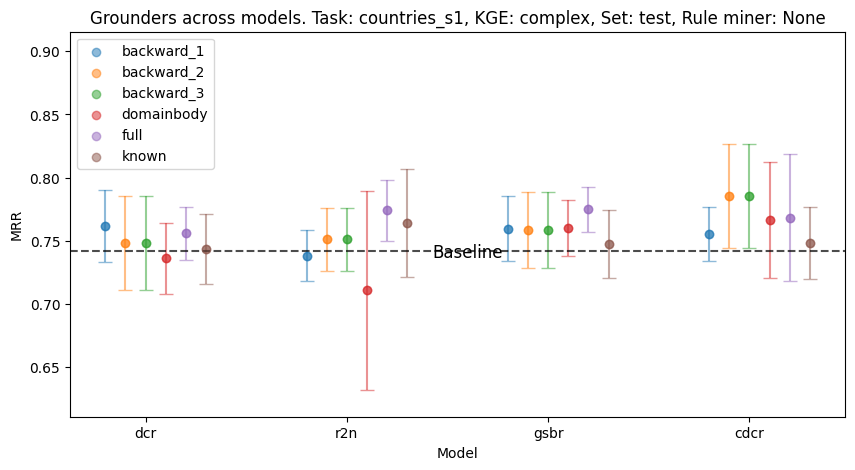

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  None
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.7609      0.7393      0.7585  0.7383
dcr              0.7735      0.7278      0.7384  0.7452
gsbr             0.7526      0.7388      0.7412  0.7317
no_reasoner      0.7256      0.7256      0.7256  0.7256
r2n              0.7972      0.7511      0.7585  0.7813
<built-in method min of numpy.ndarray object at 0x000001D12A6D4A50>


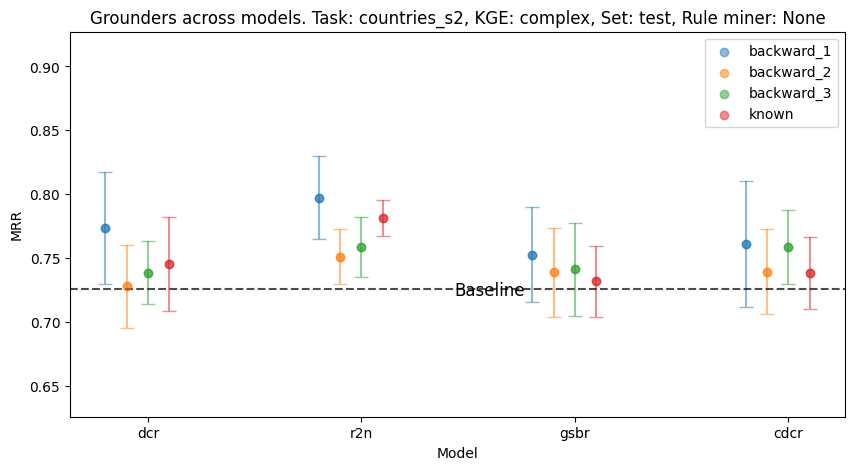

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  ncrl
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  None
Grounder     backward_1  backward_2  backward_3   known
Model_name                                             
cdcr             0.6120      0.6006      0.5948  0.5908
dcr              0.6123      0.5945      0.6061  0.6092
gsbr             0.6098      0.5896      0.6101  0.6094
no_reasoner      0.6078      0.6078      0.6078  0.6078
r2n              0.6120      0.6431      0.6229  0.6249
<built-in method min of numpy.ndarray object at 0x000001D12A6E9650>


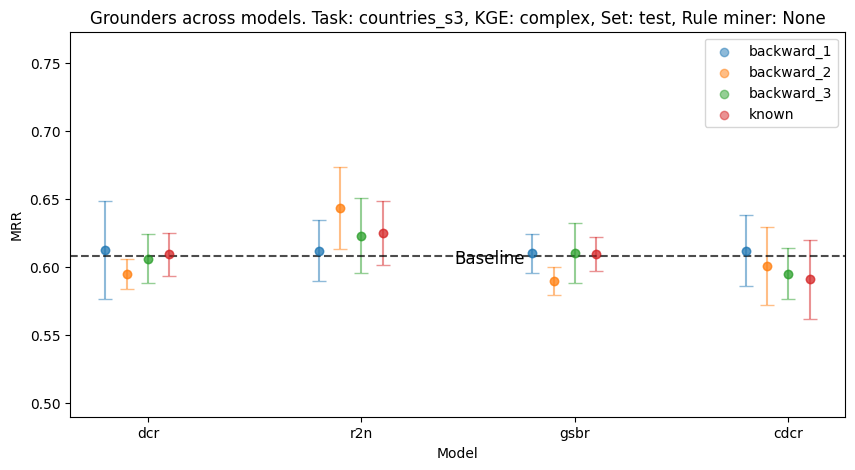

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  ncrl


In [305]:
# Table 1: rows:grounder, cols:Model, values: mrr
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\figures\\"
os.makedirs(root_dir) if not os.path.exists(root_dir) else None
for task in tasks:
    for metric in ['test_task_mrr']:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                if rule_miner not in dfs[task][KGE][metric].keys():
                    continue
                df_mean = dfs[task][KGE][metric][rule_miner]['mean']
                df_std = dfs[task][KGE][metric][rule_miner]['std']
                print(df_mean)
                # Remove no reasoner and include a line where it is written baseline
                plt.figure(figsize=(10,5))
                for i,grounder in enumerate(df_mean.loc[models_no_baseline].columns):
                    plt.scatter(np.arange(len(df_mean.loc[models_no_baseline].index))+0.1*i, df_mean.loc[models_no_baseline][grounder], label=grounder, alpha=0.5)
                    plt.errorbar(np.arange(len(df_mean.loc[models_no_baseline].index))+0.1*i, df_mean.loc[models_no_baseline][grounder], yerr=df_std.loc[models_no_baseline][grounder], fmt='o',capsize=5, alpha=0.5)
                if metric == step+'_task_mrr':
                    plt.axhline(y=df_mean.loc[baseline_model].mean(), color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                    plt.text(1.8, df_mean.loc[baseline_model].mean()-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                    # print(df_mean.loc[baseline_model].values[0])
                plt.legend()
                plt.xticks(np.arange(len(df_mean.loc[models_no_baseline].index))+0.2, df_mean.loc[models_no_baseline].index.tolist(), rotation=0)
                plt.ylabel(metric_names[metric])
                plt.xlabel('Model')
                min = np.array([i for i in df_mean.loc[models].values.ravel() if i != np.nan])
                max = np.array([i for i in df_mean.loc[models].values.ravel() if i != np.nan])
                if min.min()<10:
                    print(min.min)
                    plt.ylim(min.min()-0.1,max.max()+0.13)
                plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
                plt.show()
                # SAVE THE FIGURE
                # if the directory does not exist, create it
                # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

In [251]:
# # Now do the plot of the average over the models
# for task in tasks:
#     for metric in ['test_task_mrr']:
#         for KGE in KGEs:
#             for rule_miner in ['None', 'amie', 'ncrl']:
#                 print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                 if rule_miner not in dfs[task][KGE][metric].keys():
#                     continue
#                 df_mean = dfs_avg[task][KGE][metric][rule_miner]['mean']
#                 print(df_mean)
#                 df_std = dfs_avg[task][KGE][metric][rule_miner]['std']
#                 # Remove no reasoner and include a line where it is written baseline
#                 plt.figure(figsize=(10,5))
#                 plt.scatter(np.arange(len(df_mean.index)),df_mean.values.flatten(), alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index)),df_mean.values.flatten(), yerr=df_std.values.flatten(), fmt='o',capsize=5, alpha=0.5)
#                 if metric == step+'_task_mrr':
#                     baseline = dfs[task][KGE][metric][rule_miner]['mean'].loc[baseline_model].mean()
#                     plt.axhline(y=baseline, color='black', linestyle='--', alpha=.7)   
#                     plt.text(1.8, baseline-0.005, 'Baseline', color='black', fontsize=12, ha='center')
#                 # in the xlabel put the names of the grounders
#                 plt.xticks(np.arange(len(df_mean.index)), df_mean.index.tolist(), rotation=0)
#                 plt.ylabel(metric_names[metric])
#                 min = np.array([i for i in df_mean.values.flatten() if i != np.nan])
#                 max = np.array([i for i in df_mean.values.flatten() if i != np.nan])
#                 print(min.min() is np.nan)
#                 if min.min()<1:
#                     print(min.min)
#                     plt.ylim(min.min()-0.1,max.max()+0.1)
#                 plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
#                 plt.show()
#                 # SAVE THE FIGURE
#                 # if the directory does not exist, create it
#                 # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

# Grounders in x axis

In [18]:
rows = 'grounder'
cols = 'model_name'
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
# create the dict dfs with 4 levels of keys: task, KGE, metric, rule_miner
dfs = nested_dict(4, dict)
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('\nTask: ', task, 'KGE: ', KGE, ' Metric: ', metric,  ' Rule miner: ', rule_miner)
                # verify that the rule miner is within the values of Rule_Miner, else continue
                
                miners_available = df.loc[ (df['dataset_name'] == task) &(df['kge'] == KGE)]['rule_miner'].apply(lambda x: str(x)).unique()
                if (rule_miner not in miners_available):
                    # print('Not available: rule_miner',rule_miner,'. Available: ',miners_available)
                    continue
                # print('miners_available',miners_available)
                # print('rule_miner',rule_miner)
                # print('rul miner in miners_available',rule_miner in miners_available)
                # filter the df
                results = df.loc[ (df['dataset_name'] == task) &(df['kge'] == KGE) &(df['rule_miner'] == rule_miner) & df['grounder'].isin(grounders)].copy() #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
                # take only the columns grounder, model, test_task_mrr, test_concept_mrr
                results = results[[cols, rows, metric]]
                # Remove duplicates
                results = drop_duplicates_except_metric(results,cols,rows)
                # put the model_name as colums
                results = results.pivot(index=rows, columns=cols, values=metric)
                # print('results',results)
                # print('metric',metric)  
                if metric == 'test_task_mrr':
                    # in the column no_reasoner, put the values of the column test_concept_mrr
                    substitute = df.loc[(df['dataset_name'] == task) & (df['kge'] == KGE) &(df['rule_miner'] == rule_miner) & (df['model_name'] == baseline_model)][[cols,rows,baseline_metric]] #& (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                    # drop the duplicates , based on all the colums except for 'test_task_mrr'
                    substitute = drop_duplicates_except_metric(substitute,cols,rows)
                    substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                    # substitute the values in the table
                    if len(substitute) > 0:
                        results[baseline_model] = substitute[baseline_model] 
                    # print('\nsubstitute',results)
                
                # obtain one df for the mean and one for the std
                results_mean, results_std = split_df(results)
                # append the results to dfs
                dfs[task][KGE][metric][rule_miner]['mean'] = results_mean
                dfs[task][KGE][metric][rule_miner]['std'] = results_std
                # print('results_mean',results_mean)
                
                # with open(csv_dir, 'a') as f:
                #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
                #     f.write('\n ') 
                # results.to_csv(csv_dir, mode='a', header=True)  
print(task, KGE, metric, rule_miner)
results_mean


Task:  countries_s1 KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  countries_s1 KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  countries_s2 KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  countries_s2 KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  countries_s3 KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  countries_s3 KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  nations KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  nations KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  kinship_family KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  kinship_family KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  pharmkg_small KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Task:  pharmkg_small KGE:  complex  Metric:  test_task_mrr  Rule miner:  amie

Task:  pharmkg_full KGE:  complex  Metric:  test_task_mrr  Rule miner:  No

Tas

model_name,no_reasoner
grounder,
backward_1,0.587


KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s1  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  No
Best result:  0.92 Baseline:  0.916


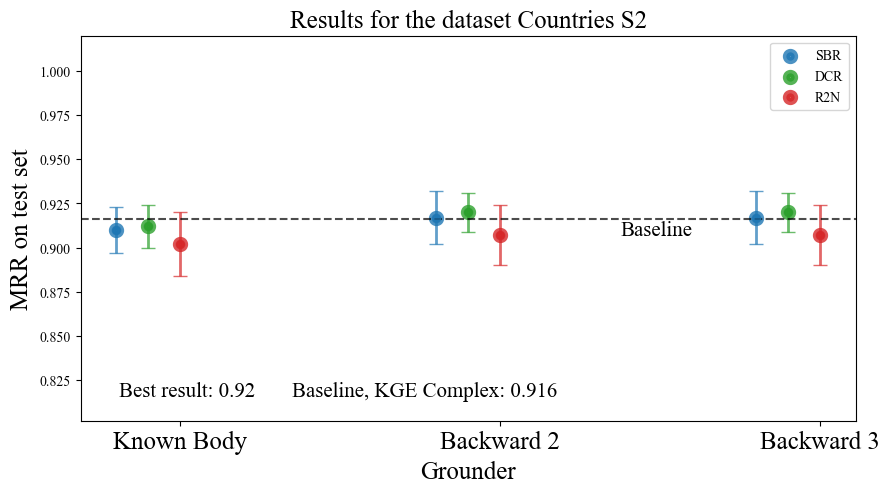

KGE:  complex  Metric:  test_task_mrr  Task:  countries_s2  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  No
Best result:  0.968 Baseline:  0.838


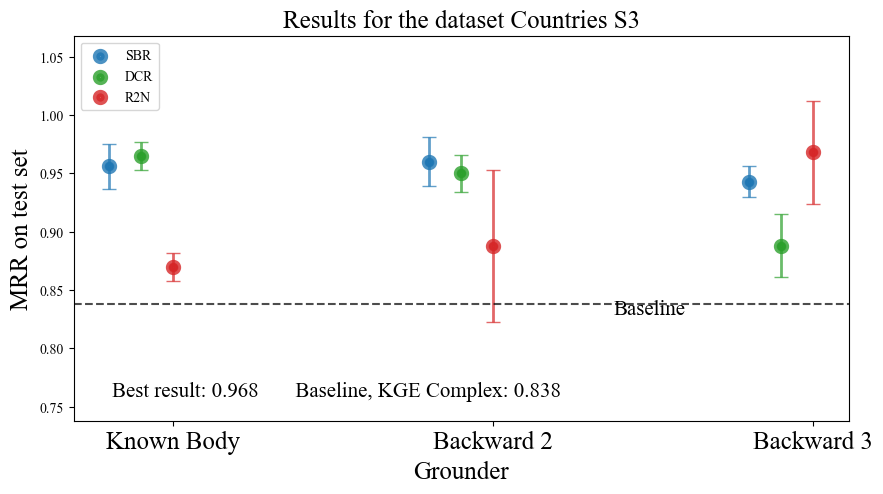

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


KGE:  complex  Metric:  test_task_mrr  Task:  countries_s3  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  nations  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  kinship_family  Rule miner:  amie
Best result:  0.587 Baseline:  0.587


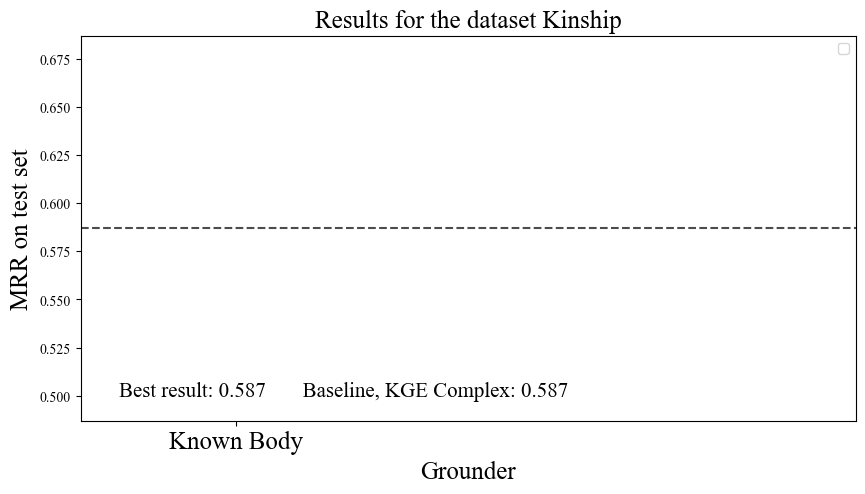

KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_small  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_small  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_full  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  pharmkg_full  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  FB15k237  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  FB15k237  Rule miner:  amie
KGE:  complex  Metric:  test_task_mrr  Task:  wn18rr  Rule miner:  No
KGE:  complex  Metric:  test_task_mrr  Task:  wn18rr  Rule miner:  amie


In [19]:
# select the times new roman font
plt.rcParams['font.family'] = 'Times New Roman'
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\figures\\"
for task in tasks:
    for metric in metrics:
        for KGE in KGEs:
            for rule_miner in rule_miners:
                print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
                if rule_miner not in dfs[task][KGE][metric].keys():
                    continue
                subset_models = [i for i in models_no_baseline if i in list(dfs[task][KGE][metric][rule_miner]['mean'].keys())]
                df_mean = dfs[task][KGE][metric][rule_miner]['mean'][subset_models]                    
                df_std = dfs[task][KGE][metric][rule_miner]['std'][subset_models]
                try:
                    df_mean_baseline = dfs[task][KGE][metric][rule_miner]['mean'][baseline_model].mean()
                    baseline_found = True
                except:
                    baseline_found = False
                # df_std_baseline = dfs[task][KGE][metric][rule_miner]['std'][baseline_model]
                # Remove no reasoner and include a line where it is written baseline
                plt.figure(figsize=(10,5))
                for i,model in enumerate(df_mean.columns):
                    color = model_colors[model]
                    try:
                        plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[model], label=models_name[model], alpha=.8,linewidth=5,color=color) 
                        plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[model], yerr=df_std[model], fmt='o',capsize=5, alpha=.7,linewidth=2,color=color)
                    except:
                        continue
                plt.legend()
                labels = [ground_name[i] for i in df_mean.index]
                plt.xticks(np.arange(len(df_mean.index))+0.2, labels, rotation=0, fontsize=18)
                plt.ylabel(metric_names[metric]+' on '+step+' set', fontsize=18)
                plt.xlabel('Grounder', fontsize=18)
                min = np.array([i for i in dfs[task][KGE][metric][rule_miner]['mean'].values.ravel() if not np.isnan(i)])  
                max = np.array([i for i in dfs[task][KGE][metric][rule_miner]['mean'].values.ravel() if not np.isnan(i)]) 

                if min.min()<1: #max.max()<=.9:
                    plt.ylim(min.min()-0.1,max.max()+0.1)
                # elif max.max()>=.9:
                #     plt.ylim(min.min()-0.1,1.01)
                if metric == step+'_task_mrr' and baseline_found:
                    print('Best result: ',max.max(), 'Baseline: ', np.round(df_mean_baseline,3))
                    plt.axhline(y=df_mean_baseline, color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                    plt.text(1.8, df_mean_baseline-0.009, 'Baseline', color='black', fontsize=15, ha='right',clip_on=True)
                    plt.text(0.05, 0.05, 'Best result: '+str(np.round(max.max(),3))+'       Baseline, KGE Complex: '+str(np.round(df_mean_baseline,3)), transform=plt.gca().transAxes,
                            fontsize=15, verticalalignment='bottom', horizontalalignment='left')
                plt.title(f'Results for the dataset {dataset_names[task]}', fontsize=18)
                # plt.title(f'Dataset: {dataset_names[task]}, KGE: {KGE}, Set: {step}, Rule miner: {rule_miner}')
                plt.show()
                # SAVE THE FIGURE
                # if the directory does not exist, create it
                # os.makedirs(root_dir) if not os.path.exists(root_dir) else None
                # plt.savefig(root_dir+'Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'_rule_'+rule_miner+'.png', dpi=300, bbox_inches='tight')  

In [308]:
# # for every df of dfs, create a new df with the average over the models
# dfs_avg = nested_dict(4, dict)
# for task in tasks:
#     for metric in metrics:
#         for KGE in KGEs:
#             for rule_miner in rule_miners:
#                 for types in ['mean', 'std']:
#                     # print(types, 'KGE: ', KGE, ' Metric: ', metric, ' Task: ', task, ' Rule miner: ', rule_miner)
#                     if rule_miner not in dfs[task][KGE][metric].keys():
#                         continue
#                     dfi = dfs[task][KGE][metric][rule_miner][types].copy()
#                     # select from dfi the models that are in models_no_baseline
#                     dfi = dfi[models_no_baseline]
#                     dfi = dfi.mean(axis=0)
#                     dfi = pd.DataFrame(dfi)
#                     # set the name of the column as the metric
#                     dfi.columns = [metric]
#                     dfs_avg[task][KGE][metric][rule_miner][types] = dfi
#                     # print(dfi)
# dfi

- amie vs ncrl: amie is better
- models: no difference between models
- improvement over baseline: all datasets (kinship family, pharmkg, countries) excep nations 
    - in the rules generated, the grounder performance depends on the rules generator?
    - models: no best model
    - grounders: no best grounder overall, then go for back1 because of computing time. Do plot with axis inverted

